# Image Classification with EfficientNet-B0 (PyTorch)

This notebook provides a complete pipeline for training and evaluating an image classification model using PyTorch and the EfficientNet-B0 architecture, pretrained on ImageNet. The goal is to classify images of nuts into one of five categories: Deformation, Excellent, Fracture, Rusting, and Scratches.

## 1. Setup and Environment Configuration

In [3]:
# Install necessary libraries
!pip install -q timm scikit-learn

import os
import zipfile
import random
import shutil
import numpy as np
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
import torchvision # Explicitly import torchvision
from torchvision import datasets, transforms
import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm.notebook import tqdm

# Set reproducible random seeds
def set_all_seeds(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you use multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_all_seeds(SEED)

# Check for GPU availability and print details
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Cores: {torch.cuda.get_device_properties(0).multi_processor_count}")

# Print PyTorch and torchvision versions
print(f"PyTorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")


Using device: cuda
GPU Name: Tesla T4
CUDA Cores: 40
PyTorch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Dataset Extraction and Exploration

In [4]:
# Define the path to the uploaded ZIP file
zip_path = '/content/nutSurfaceDataset.zip'
extract_dir_base = '/content/extracted_dataset/'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir_base, exist_ok=True)

# Extract the ZIP file
print(f"Extracting {zip_path} to {extract_dir_base}...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir_base)
print("Extraction complete.")

# Automatically locate train and val directories
train_dir = None
val_dir = None

for root, dirs, files in os.walk(extract_dir_base):
    if 'train' in dirs:
        train_dir = os.path.join(root, 'train')
    if 'val' in dirs:
        val_dir = os.path.join(root, 'val')
    if train_dir and val_dir:
        break

if not train_dir or not val_dir:
    raise FileNotFoundError("Could not find 'train' or 'val' directories within the extracted dataset.")

print(f"Located training directory: {train_dir}")
print(f"Located validation directory: {val_dir}")

# Verify classes and count images
expected_classes = ['Deformation', 'Excellent', 'Fracture', 'Rusting', 'Scratches']

def check_and_count_images(data_dir, phase):
    class_counts = {}
    found_classes = sorted(os.listdir(data_dir))
    print(f"\n--- {phase} Dataset --- ")
    print(f"Found classes: {found_classes}")

    # Verify all expected classes are present
    for cls in expected_classes:
        if cls not in found_classes:
            raise ValueError(f"Expected class '{cls}' not found in {data_dir}")

    for cls in found_classes:
        class_path = os.path.join(data_dir, cls)
        if os.path.isdir(class_path):
            num_images = len([name for name in os.listdir(class_path) if name.endswith(('.jpg', '.jpeg', '.png'))])
            class_counts[cls] = num_images
    return class_counts

train_class_counts = check_and_count_images(train_dir, 'Training')
val_class_counts = check_and_count_images(val_dir, 'Validation')

print("\nNumber of images in each class (Training set):")
for cls, count in train_class_counts.items():
    print(f"  {cls}: {count} images")

print("\nNumber of images in each class (Validation set):")
for cls, count in val_class_counts.items():
    print(f"  {cls}: {count} images")

# Get class names from the dataset (they should match expected_classes)
class_names = sorted(expected_classes)
print(f"\nClass names (sorted): {class_names}")


Extracting /content/nutSurfaceDataset.zip to /content/extracted_dataset/...
Extraction complete.
Located training directory: /content/extracted_dataset/nutsv2ifolder_split/train
Located validation directory: /content/extracted_dataset/nutsv2ifolder_split/val

--- Training Dataset --- 
Found classes: ['Deformation', 'Excellent', 'Fracture', 'Rusting', 'Scratches']

--- Validation Dataset --- 
Found classes: ['Deformation', 'Excellent', 'Fracture', 'Rusting', 'Scratches']

Number of images in each class (Training set):
  Deformation: 1471 images
  Excellent: 249 images
  Fracture: 229 images
  Rusting: 423 images
  Scratches: 378 images

Number of images in each class (Validation set):
  Deformation: 368 images
  Excellent: 63 images
  Fracture: 58 images
  Rusting: 106 images
  Scratches: 95 images

Class names (sorted): ['Deformation', 'Excellent', 'Fracture', 'Rusting', 'Scratches']


## 3. Visualize Sample Images

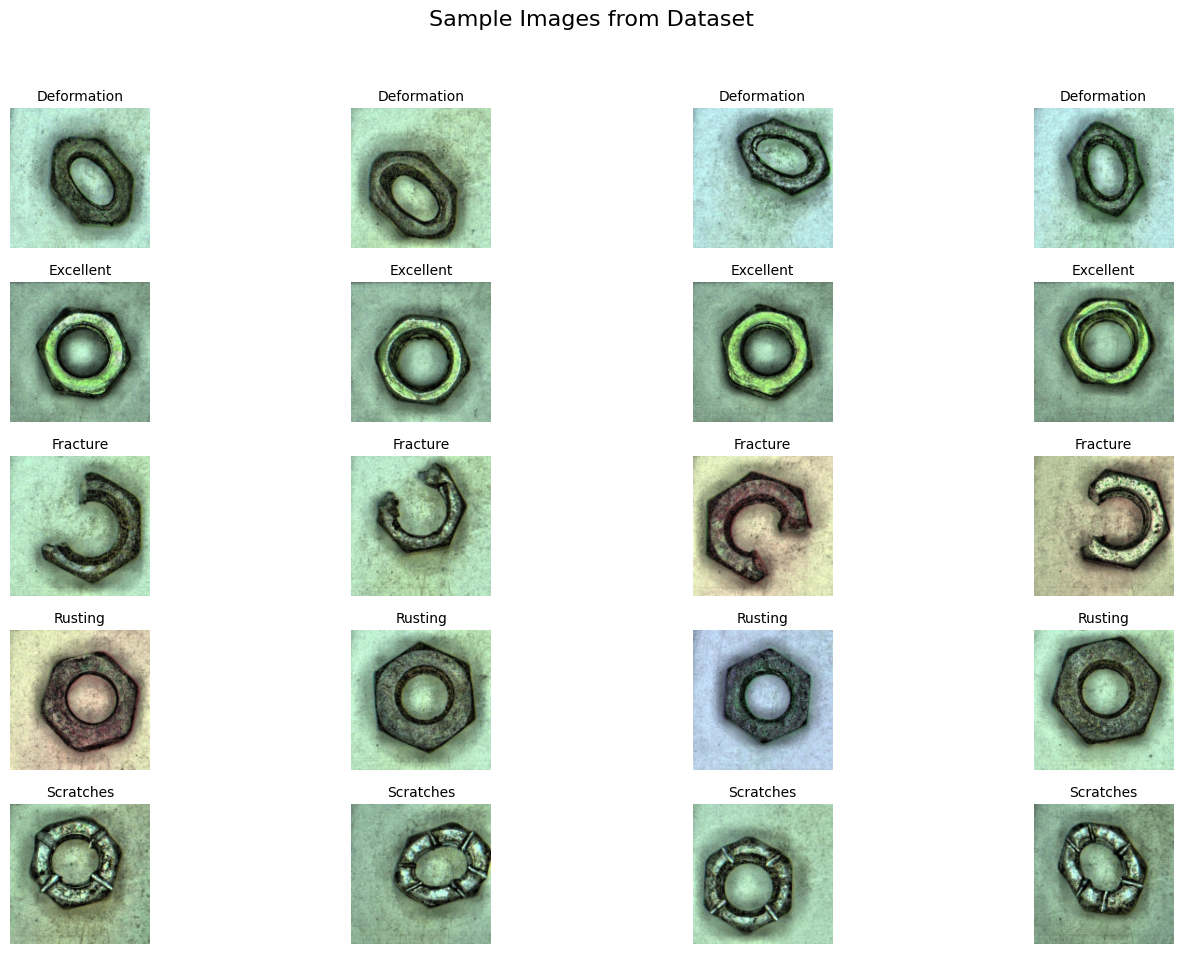

In [5]:
def visualize_samples(data_dir, class_names, num_samples=5):
    plt.figure(figsize=(15, 10))
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
        selected_images = random.sample(images, min(num_samples, len(images)))

        for j, img_name in enumerate(selected_images):
            img_path = os.path.join(class_path, img_name)
            img = plt.imread(img_path)

            ax = plt.subplot(len(class_names), num_samples, i * num_samples + j + 1)
            plt.imshow(img)
            plt.title(f"{class_name}", fontsize=10)
            plt.axis('off')
    plt.suptitle('Sample Images from Dataset', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

visualize_samples(train_dir, class_names, num_samples=4)

## 4. Data Preprocessing and Data Loaders

In [6]:
# ImageNet normalization values
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Define data transformations
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224), # Consistent with EfficientNet-B0 input size
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15), # Moderate rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

val_transforms = transforms.Compose([
    transforms.Resize(256), # Resize to a larger size first
    transforms.CenterCrop(224), # Then crop to 224x224
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Create datasets using ImageFolder
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

# Create data loaders
BATCH_SIZE = 32 # You can adjust this based on your GPU memory

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in validation loader: {len(val_loader)}")

# Verify class_to_idx mapping
print("\nDataset class_to_idx mapping:")
print(train_dataset.class_to_idx)

# Ensure the order of class_names matches the dataset's target labels
# The dataset.class_to_idx gives us the mapping from class_name to integer label.
# We want the reverse: list of class_names by integer label index.
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print(f"Final ordered class names for model output: {class_names}")

# Verify the number of classes matches expectations
if len(class_names) != 5:
    raise ValueError(f"Expected 5 classes, but found {len(class_names)}. Check dataset structure.")


Number of training samples: 2750
Number of validation samples: 690
Number of batches in training loader: 86
Number of batches in validation loader: 22

Dataset class_to_idx mapping:
{'Deformation': 0, 'Excellent': 1, 'Fracture': 2, 'Rusting': 3, 'Scratches': 4}
Final ordered class names for model output: ['Deformation', 'Excellent', 'Fracture', 'Rusting', 'Scratches']


## 5. Class Imbalance Analysis

Class distribution in training set:
  Deformation: 1471 images (53.49%)
  Excellent: 249 images (9.05%)
  Fracture: 229 images (8.33%)
  Rusting: 423 images (15.38%)
  Scratches: 378 images (13.75%)

Calculated class weights (normalized):
  Deformation: 0.0483
  Excellent: 0.2854
  Fracture: 0.3103
  Rusting: 0.1680
  Scratches: 0.1880


/tmp/ipykernel_1057/321455828.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts_ordered, palette='viridis')


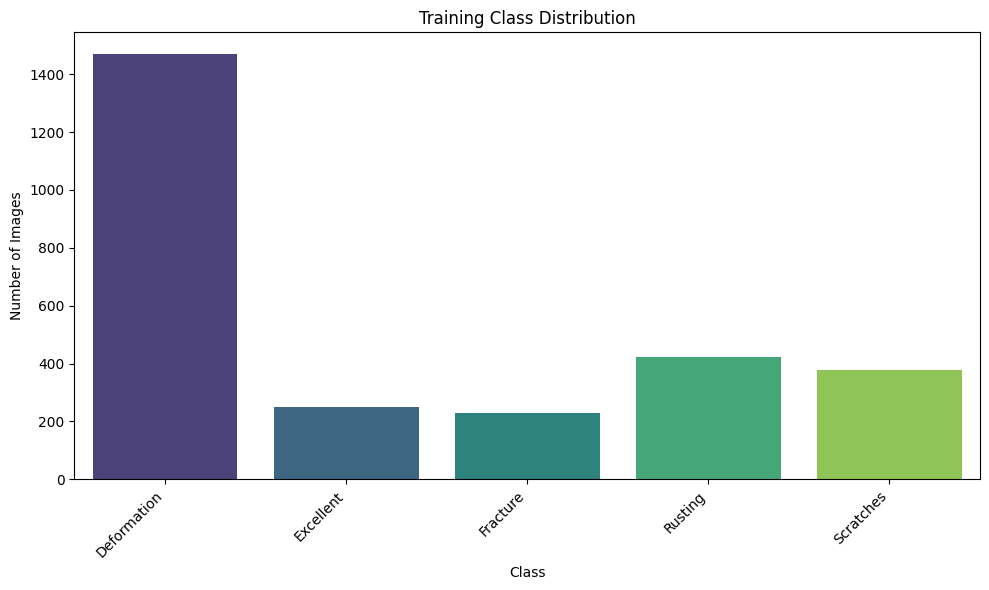

In [7]:
# Calculate class frequencies for the training set
train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)

# Convert counts to a list in the order of class_names
class_counts_ordered = [class_counts[i] for i in range(len(class_names))]
total_samples = sum(class_counts_ordered)

print("Class distribution in training set:")
for i, count in enumerate(class_counts_ordered):
    print(f"  {class_names[i]}: {count} images ({count/total_samples:.2%})")

# Calculate class weights for CrossEntropyLoss
# Weights = 1 / frequency
class_weights = torch.tensor([total_samples / count for count in class_counts_ordered], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() # Normalize weights
class_weights = class_weights.to(device)

print("\nCalculated class weights (normalized):")
for i, weight in enumerate(class_weights.cpu().numpy()):
    print(f"  {class_names[i]}: {weight:.4f}")

# Plot class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=class_names, y=class_counts_ordered, palette='viridis')
plt.title('Training Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Based on the training class distribution, there appears to be some imbalance. For instance, 'Excellent' and 'Deformation' classes have a higher number of samples compared to 'Rusting' and 'Scratches'. To address this, **class weighting will be used** in the `CrossEntropyLoss` function. This will give more importance to the under-represented classes during training, helping the model to learn better from them and improve overall performance.

## 6. Build EfficientNet-B0 Model

In [8]:
def build_model(num_classes):
    # Load pre-trained EfficientNet-B0
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

    # Freeze all parameters in the feature extractor
    for param in model.parameters():
        param.requires_grad = False

    # Replace the classifier head
    # EfficientNet's classifier is `model.classifier` which is a Sequential of Dropout, Linear
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True), # Default dropout rate for EfficientNet-B0
        nn.Linear(num_ftrs, num_classes)
    )

    # Move model to device
    model = model.to(device)
    return model

model = build_model(len(class_names))
print(model)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 165MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

## 7. Training Functions (Stages 1 and 2)

In [9]:
from sklearn.metrics import f1_score

def train_model(
    model, dataloaders, criterion, optimizer, scheduler, num_epochs=25, checkpoint_path='best_efficientnet_b0.pth',
    device=device, use_amp=False, early_stopping_patience=5
):
    best_model_wts = model.state_dict()
    best_f1 = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []}
    epochs_no_improve = 0

    if use_amp and device.type == 'cuda':
        scaler = torch.cuda.amp.GradScaler()
        print("Using Automatic Mixed Precision (AMP).")
    else:
        print("AMP not used or device is not CUDA.")

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            # Use tqdm for a progress bar
            for inputs, labels in tqdm(dataloaders[phase], desc=f'{phase} Epoch {epoch+1}'):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    if use_amp and device.type == 'cuda':
                        with torch.cuda.amp.autocast():
                            outputs = model(inputs)
                            _, preds = torch.max(outputs, 1)
                            loss = criterion(outputs, labels)
                    else:
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        if use_amp and device.type == 'cuda':
                            scaler.scale(loss).backward()
                            scaler.step(optimizer)
                            scaler.update()
                        else:
                            loss.backward()
                            optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            epoch_f1 = f1_score(all_labels, all_preds, average='macro') # Macro F1 for imbalance

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                history['lr'].append(optimizer.param_groups[0]['lr'])
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                history['val_f1'].append(epoch_f1)

                # Step the scheduler based on validation F1-score
                if scheduler is not None:
                    if isinstance(scheduler, lr_scheduler.ReduceLROnPlateau):
                        scheduler.step(epoch_f1)
                    else: # For other schedulers that step per epoch
                        scheduler.step()

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} F1 (Macro): {epoch_f1:.4f}')

            # Save best model based on validation F1-score
            if phase == 'val' and epoch_f1 > best_f1:
                best_f1 = epoch_f1
                best_model_wts = model.state_dict()
                torch.save(model.state_dict(), checkpoint_path)
                epochs_no_improve = 0
                print(f"Model improved, saving best model with F1: {best_f1:.4f}")
            elif phase == 'val':
                epochs_no_improve += 1
                print(f"Epochs without improvement: {epochs_no_improve}")

        # Early stopping check
        if epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered after {early_stopping_patience} epochs without improvement.")
            break

    print(f'Training complete. Best Val F1: {best_f1:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history, best_f1



### 7.1 Stage 1 Training: Train Classifier Only

In [10]:
# Rebuild model to ensure feature extractor is frozen (important if we modified it earlier)
model_stage1 = build_model(len(class_names))

# Only classifier parameters require gradients for Stage 1
optimizer_stage1 = optim.AdamW(model_stage1.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=class_weights) # Use class-weighted loss
scheduler_stage1 = lr_scheduler.ReduceLROnPlateau(optimizer_stage1, mode='max', factor=0.1, patience=3) # Removed verbose=True

dataloaders = {'train': train_loader, 'val': val_loader}

print("\nStarting Stage 1: Training classifier only...")
model_stage1, history_stage1, best_f1_stage1 = train_model(
    model_stage1, dataloaders, criterion, optimizer_stage1, scheduler_stage1, num_epochs=10,
    checkpoint_path='/content/best_efficientnet_b0_stage1.pth', device=device, use_amp=True,
    early_stopping_patience=5
)

print("Stage 1 Training Complete.")



Starting Stage 1: Training classifier only...
Using Automatic Mixed Precision (AMP).

Epoch 1/10
----------


/tmp/ipykernel_1057/3101910983.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


train Epoch 1:   0%|          | 0/86 [00:00<?, ?it/s]

/tmp/ipykernel_1057/3101910983.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


train Loss: 1.0579 Acc: 0.5702 F1 (Macro): 0.5673


...

/tmp/ipykernel_1057/3101910983.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


train Loss: 0.4672 Acc: 0.8098 F1 (Macro): 0.7912


val Epoch 10:   0%|          | 0/22 [00:00<?, ?it/s]

/tmp/ipykernel_1057/3101910983.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


val Loss: 0.3461 Acc: 0.8826 F1 (Macro): 0.8876
Epochs without improvement: 4
Training complete. Best Val F1: 0.8973
Stage 1 Training Complete.


### 7.2 Stage 2 Training: Fine-tune Full Network

In [11]:
# Load the best weights from Stage 1
model_stage2 = build_model(len(class_names))
model_stage2.load_state_dict(torch.load('/content/best_efficientnet_b0_stage1.pth'))

# Unfreeze all parameters for fine-tuning
for param in model_stage2.parameters():
    param.requires_grad = True

# Use a smaller learning rate for fine-tuning
optimizer_stage2 = optim.AdamW(model_stage2.parameters(), lr=1e-5) # Smaller LR
criterion = nn.CrossEntropyLoss(weight=class_weights)
scheduler_stage2 = lr_scheduler.ReduceLROnPlateau(optimizer_stage2, mode='max', factor=0.1, patience=3) # Removed verbose=True

print("\nStarting Stage 2: Fine-tuning full network...")
model_stage2, history_stage2, best_f1_stage2 = train_model(
    model_stage2, dataloaders, criterion, optimizer_stage2, scheduler_stage2, num_epochs=20,
    checkpoint_path='/content/best_efficientnet_b0.pth', device=device, use_amp=True,
    early_stopping_patience=5
)

print("Stage 2 Training Complete.")



Starting Stage 2: Fine-tuning full network...
Using Automatic Mixed Precision (AMP).

Epoch 1/20
----------


/tmp/ipykernel_1057/3101910983.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


train Epoch 1:   0%|          | 0/86 [00:00<?, ?it/s]

/tmp/ipykernel_1057/3101910983.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


train Loss: 0.4623 Acc: 0.8316 F1 (Macro): 0.8071


...

/tmp/ipykernel_1057/3101910983.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


train Loss: 0.2536 Acc: 0.9095 F1 (Macro): 0.8893


val Epoch 20:   0%|          | 0/22 [00:00<?, ?it/s]

/tmp/ipykernel_1057/3101910983.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


val Loss: 0.0708 Acc: 0.9826 F1 (Macro): 0.9782
Model improved, saving best model with F1: 0.9782
Training complete. Best Val F1: 0.9782
Stage 2 Training Complete.


## 8. Training Curves

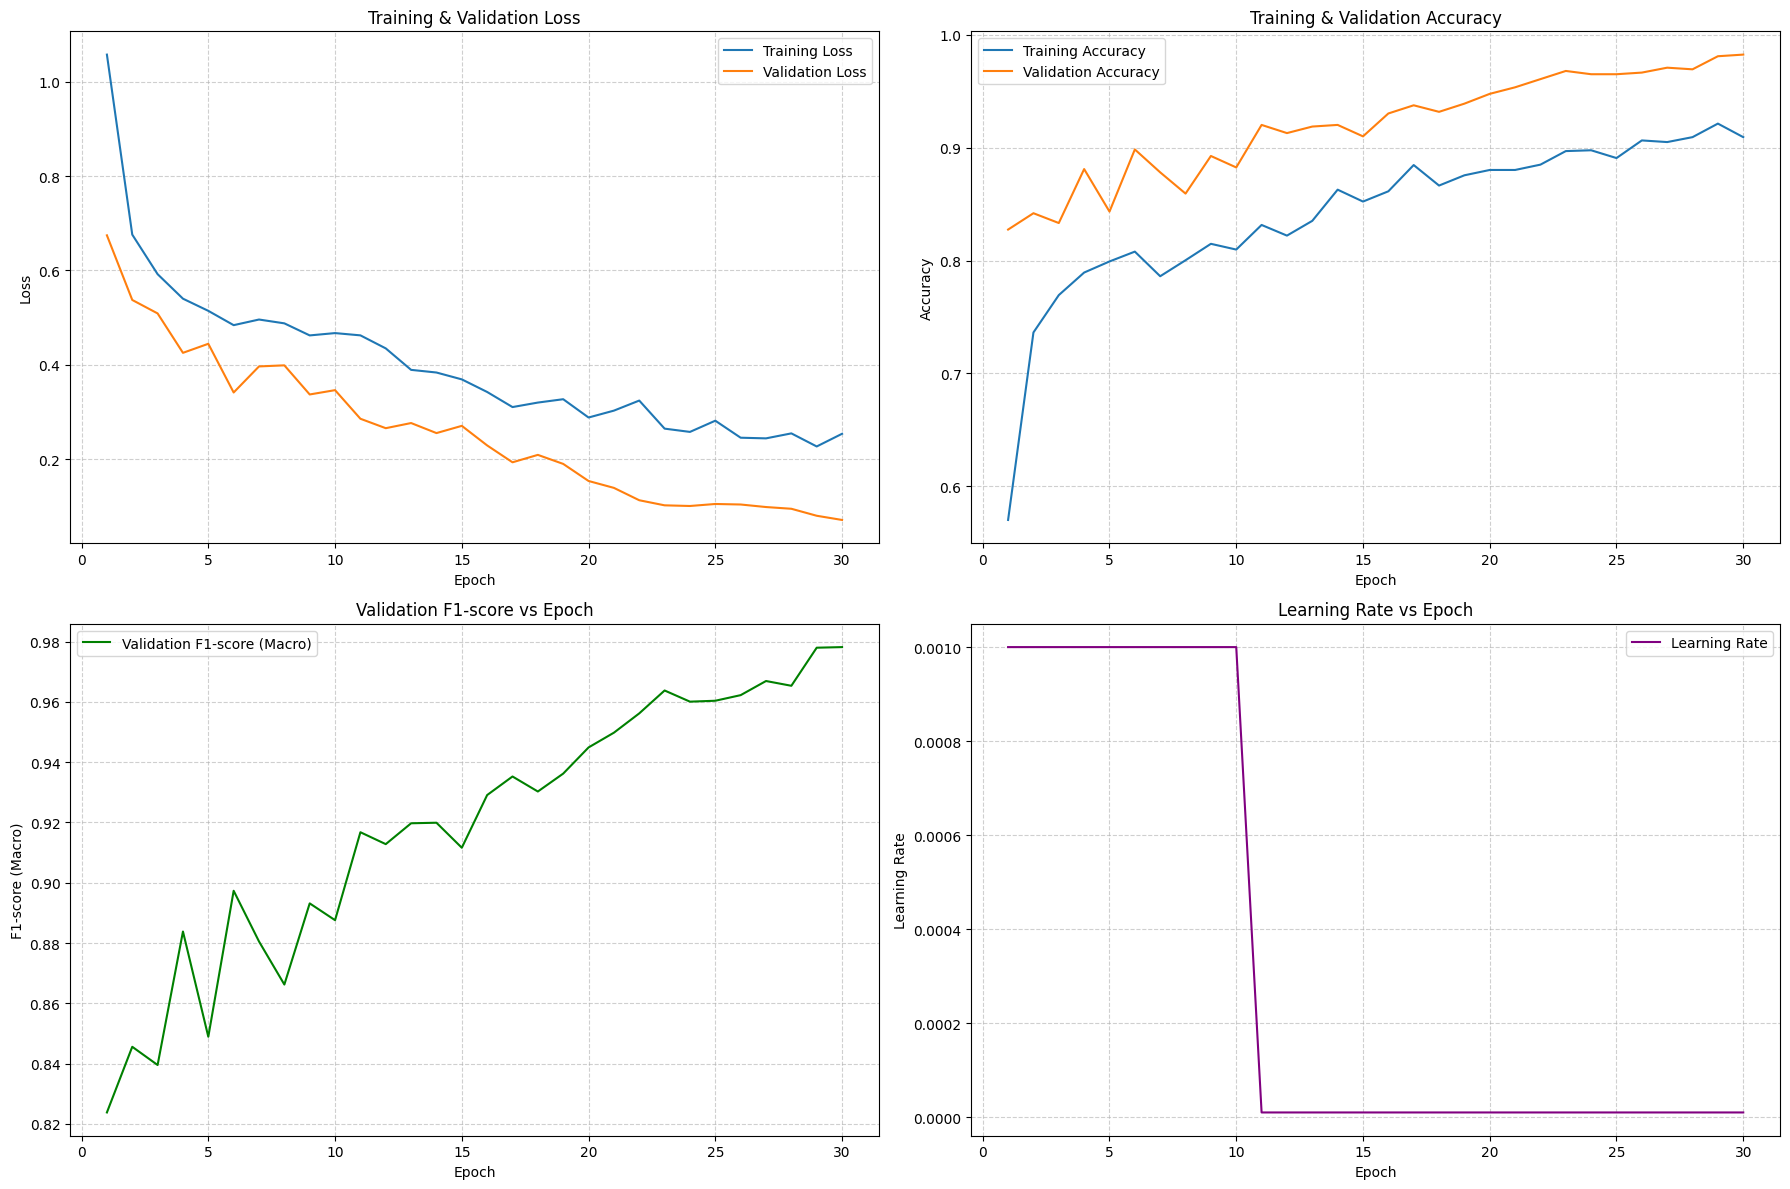

In [12]:
def plot_training_curves(history_stage1, history_stage2):
    # Combine histories for plotting
    history = {
        'train_loss': history_stage1['train_loss'] + history_stage2['train_loss'],
        'train_acc': history_stage1['train_acc'] + history_stage2['train_acc'],
        'val_loss': history_stage1['val_loss'] + history_stage2['val_loss'],
        'val_acc': history_stage1['val_acc'] + history_stage2['val_acc'],
        'val_f1': history_stage1['val_f1'] + history_stage2['val_f1'],
        'lr': history_stage1['lr'] + history_stage2['lr']
    }

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(18, 12))

    # Plot 1: Training vs Validation Loss
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Training vs Validation Accuracy
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot 3: Validation F1-score vs Epoch
    plt.subplot(2, 2, 3)
    plt.plot(epochs, history['val_f1'], label='Validation F1-score (Macro)', color='green')
    plt.title('Validation F1-score vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('F1-score (Macro)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot 4: Learning Rate vs Epoch
    plt.subplot(2, 2, 4)
    plt.plot(epochs, history['lr'], label='Learning Rate', color='purple')
    plt.title('Learning Rate vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_training_curves(history_stage1, history_stage2)


## 9. Final Evaluation

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def evaluate_model(model, dataloader, class_names, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"): # Use tqdm for progress
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    conf_mat = confusion_matrix(all_labels, all_preds)

    print("\n--- Final Validation Metrics ---")
    print(f"Validation Accuracy: {accuracy*100:.2f}%")
    print(f"Macro F1-score: {macro_f1:.4f}")
    print(f"Weighted F1-score: {weighted_f1:.4f}")
    print("\nClassification Report:")
    print(report)

    return accuracy, macro_f1, weighted_f1, conf_mat, all_labels, all_preds

# Load the best model from Stage 2 training
final_model = build_model(len(class_names)) # Rebuild model structure
final_model.load_state_dict(torch.load('/content/best_efficientnet_b0.pth'))
final_model.eval()

final_accuracy, final_macro_f1, final_weighted_f1, final_conf_mat, all_labels, all_preds = evaluate_model(
    final_model, val_loader, class_names, device
)


Evaluating:   0%|          | 0/22 [00:00<?, ?it/s]


--- Final Validation Metrics ---
Validation Accuracy: 98.41%
Macro F1-score: 0.9798
Weighted F1-score: 0.9843

Classification Report:
              precision    recall  f1-score   support

 Deformation     0.9945    0.9810    0.9877       368
   Excellent     0.8873    1.0000    0.9403        63
    Fracture     1.0000    0.9828    0.9913        58
     Rusting     0.9906    0.9906    0.9906       106
   Scratches     1.0000    0.9789    0.9894        95

    accuracy                         0.9841       690
   macro avg     0.9745    0.9867    0.9798       690
weighted avg     0.9853    0.9841    0.9843       690



## 10. Confusion Matrix

## 11. Prediction Examples

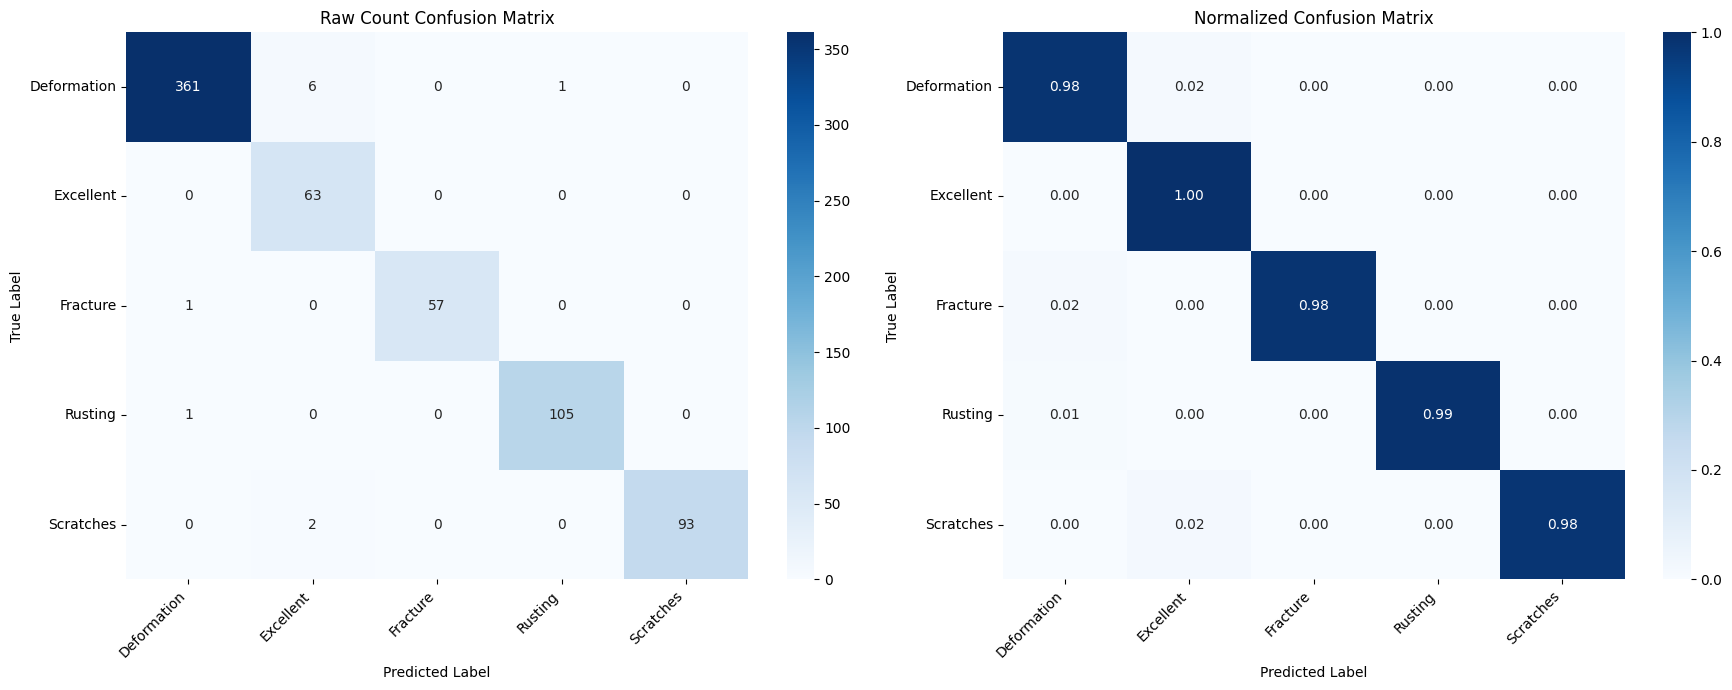


--- Most Commonly Confused Class Pairs ---
Top 5 most frequent confusion pairs (True -> Predicted):
  1. True: Scratches -> Predicted: Excellent (2.11%)
  2. True: Fracture -> Predicted: Deformation (1.72%)
  3. True: Deformation -> Predicted: Excellent (1.63%)
  4. True: Rusting -> Predicted: Deformation (0.94%)
  5. True: Deformation -> Predicted: Rusting (0.27%)


In [15]:
def plot_confusion_matrix(conf_mat, class_names, title, ax, normalize=False):
    if normalize:
        conf_mat = conf_mat.astype('float') / conf_mat.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
    else:
        fmt = 'd'

    sns.heatmap(
        conf_mat,
        annot=True,
        fmt=fmt,
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    # Rotate x-axis labels
    ax.tick_params(axis='x', rotation=45)

    # Set horizontal alignment separately
    plt.setp(ax.get_xticklabels(), ha='right')

    # Keep y-axis labels horizontal
    ax.tick_params(axis='y', rotation=0)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw Count Confusion Matrix
plot_confusion_matrix(
    final_conf_mat,
    class_names,
    'Raw Count Confusion Matrix',
    axes[0],
    normalize=False
)

# Normalized Confusion Matrix
plot_confusion_matrix(
    final_conf_mat,
    class_names,
    'Normalized Confusion Matrix',
    axes[1],
    normalize=True
)

plt.tight_layout()
plt.show()


# Identify most commonly confused class pairs
print("\n--- Most Commonly Confused Class Pairs ---")

conf_mat_norm = (
    final_conf_mat.astype('float')
    / final_conf_mat.sum(axis=1)[:, np.newaxis]
)

# Set diagonal to zero so only mistakes remain
np.fill_diagonal(conf_mat_norm, 0)

# Sort confusion pairs
confused_pairs = []

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and conf_mat_norm[i, j] > 0:
            confused_pairs.append(
                (
                    class_names[i],
                    class_names[j],
                    conf_mat_norm[i, j]
                )
            )

confused_pairs.sort(
    key=lambda x: x[2],
    reverse=True
)

if confused_pairs:

    print(
        "Top 5 most frequent confusion pairs "
        "(True -> Predicted):"
    )

    for i, (true_cls, pred_cls, proportion) in enumerate(
        confused_pairs[:5]
    ):
        print(
            f"  {i+1}. "
            f"True: {true_cls} -> "
            f"Predicted: {pred_cls} "
            f"({proportion * 100:.2f}%)"
        )

else:
    print("No significant confusion between classes observed.")


--- Visualizing Correct Predictions ---


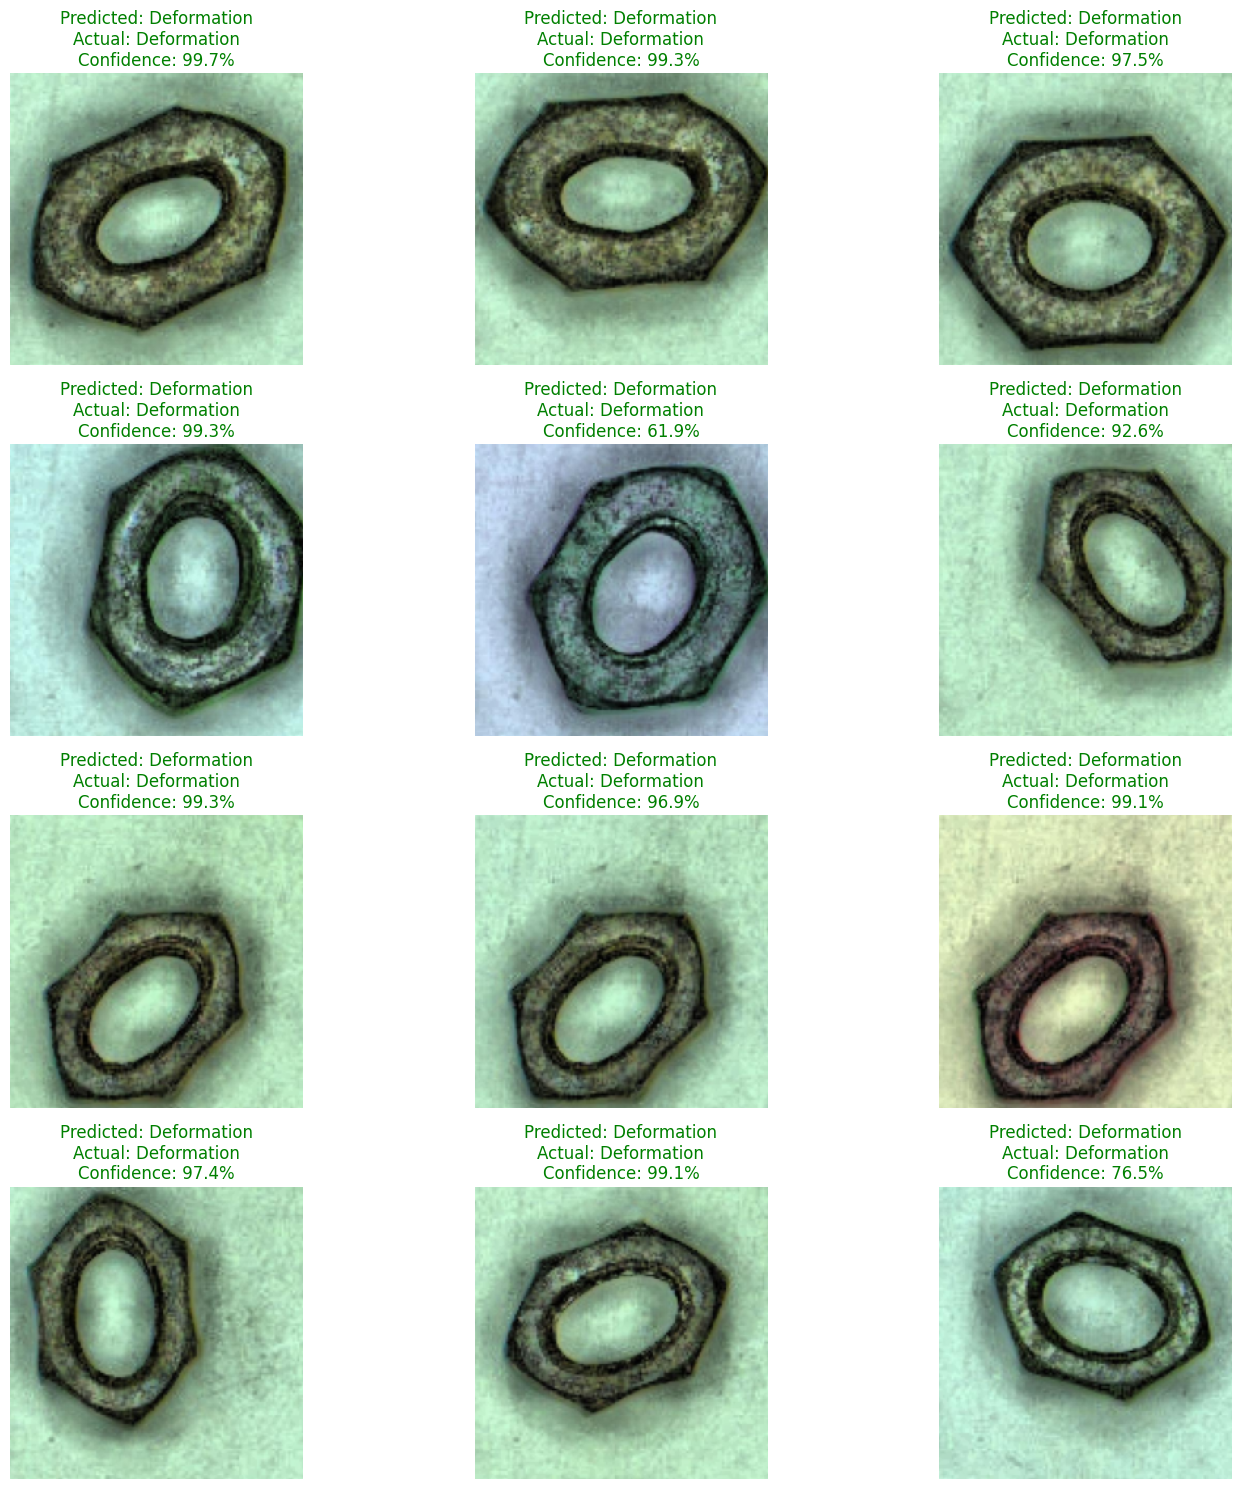

In [16]:
def visualize_predictions(model, dataloader, class_names, device, num_images=12, correct_only=True):
    model.eval()
    images_shown = 0
    fig = plt.figure(figsize=(15, 15))

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                if images_shown >= num_images:
                    break

                prediction_is_correct = (preds[j] == labels[j]).item()

                if (correct_only and prediction_is_correct) or (not correct_only and not prediction_is_correct):
                    images_shown += 1
                    ax = plt.subplot(4, 3, images_shown)
                    # Un-normalize image for display
                    img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                    img = STD * img + MEAN
                    img = np.clip(img, 0, 1)

                    plt.imshow(img)

                    predicted_class = class_names[preds[j]]
                    actual_class = class_names[labels[j]]
                    confidence = probs[j, preds[j]].item() * 100

                    title_color = "green" if prediction_is_correct else "red"

                    ax.set_title(f"Predicted: {predicted_class}\nActual: {actual_class}\nConfidence: {confidence:.1f}%",
                                 color=title_color)
                    plt.axis('off')
            if images_shown >= num_images:
                break
    plt.tight_layout()
    plt.show()

print("\n--- Visualizing Correct Predictions ---")
visualize_predictions(final_model, val_loader, class_names, device, num_images=12, correct_only=True)


## 12. Incorrect Predictions


--- Visualizing Incorrect Predictions ---


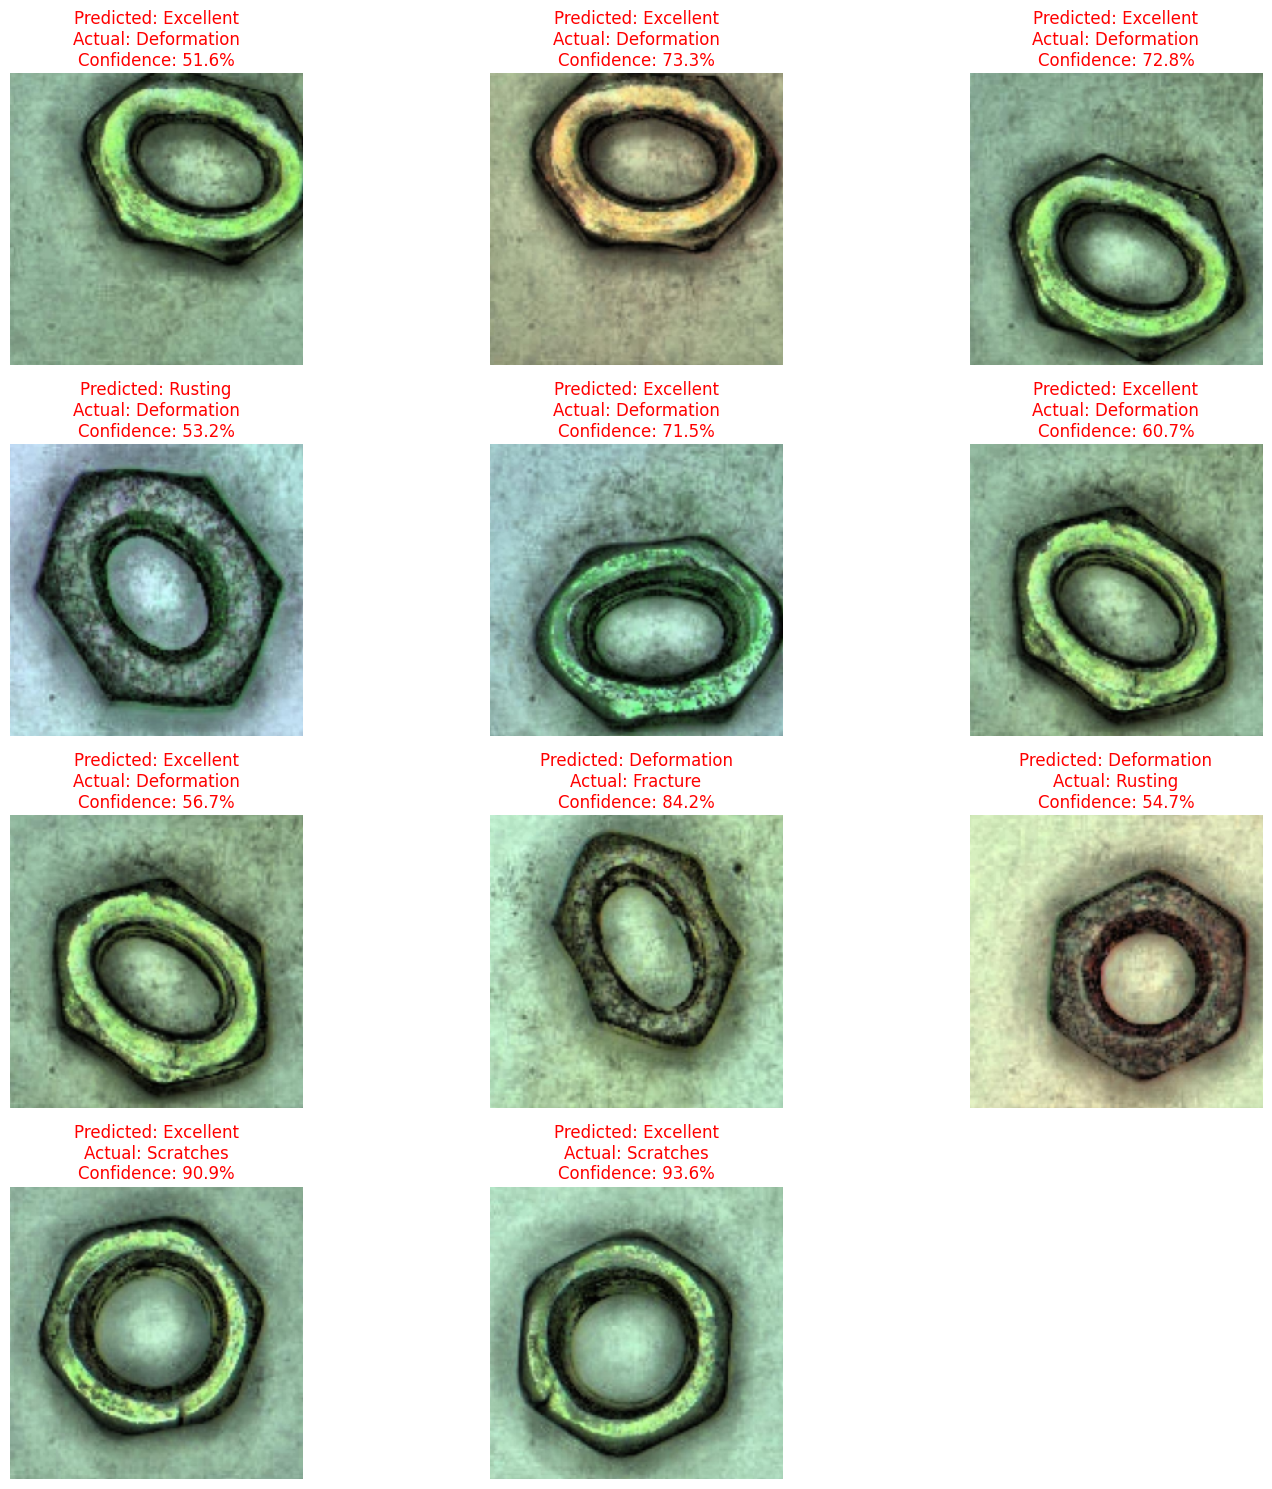

In [17]:
print("\n--- Visualizing Incorrect Predictions ---")
visualize_predictions(final_model, val_loader, class_names, device, num_images=12, correct_only=False)


## 13. Single-Image Prediction Function

Predicting for image: /content/extracted_dataset/nutsv2ifolder_split/val/Deformation/1_2021-11-17-00_48_35-065810_jpg.rf.a3bbd9ee3127ded83c9ebeccbbd6ed80.jpg


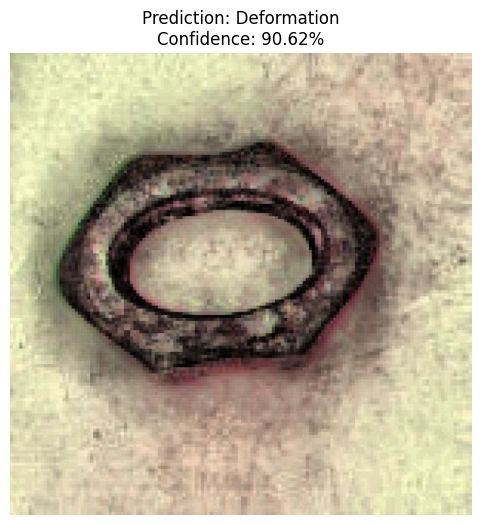


Top-5 predictions:
Deformation     90.62%
Excellent       3.88%
Rusting         3.30%
Fracture        2.01%
Scratches       0.18%


('Deformation', 0.9062076807022095)

In [18]:
from PIL import Image

def predict_image(model, image_path, class_names, device, transform):
    model.eval()

    # 1. Load image
    img = Image.open(image_path).convert('RGB')

    # 2. Apply validation preprocessing
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        # 3. Run the trained model
        outputs = model(img_tensor)
        # 4. Calculate softmax probabilities
        probs = torch.softmax(outputs, dim=1)[0]
        confidence, predicted_idx = torch.max(probs, 0)

    # 5. Return predicted class
    predicted_class = class_names[predicted_idx.item()]
    # 6. Return confidence
    confidence = confidence.item()

    # 7. Display the image
    plt.figure(figsize=(8, 6))
    plt.imshow(img) # Display the original image
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%")
    plt.axis('off')
    plt.show()

    # 8. Display top-5 class probabilities
    print("\nTop-5 predictions:")
    top5_probs, top5_indices = torch.topk(probs, 5)
    for i in range(5):
        print(f"{class_names[top5_indices[i].item()]:<15} {top5_probs[i].item()*100:.2f}%")

    return predicted_class, confidence

# Example usage:
# Pick a random image from the validation set
example_image_path = random.choice(val_dataset.imgs)[0]
print(f"Predicting for image: {example_image_path}")
predict_image(final_model, example_image_path, class_names, device, val_transforms)

# Example of an image that was likely misclassified (from confusing pairs analysis or visual inspection)
# You can manually set a path to test a specific image if needed, e.g.:
# custom_image_path = '/content/extracted_dataset/nutsv2ifolder_split/val/Deformation/img_001.jpg'
# print(f"\nPredicting for custom image: {custom_image_path}")
# predict_image(final_model, custom_image_path, class_names, device, val_transforms)


## 14. Model Saving and Loading

Best model saved at: /content/best_efficientnet_b0.pth
Model configuration saved at: /content/model_config.json

--- Demonstrating Loading Saved Model ---
Model and configuration loaded successfully.

Performing prediction with loaded model for image: /content/extracted_dataset/nutsv2ifolder_split/val/Rusting/1_2021-11-17-00_19_25-950219_jpg.rf.d2e4a61cdcd188b313d4f290ef5dcc1e.jpg


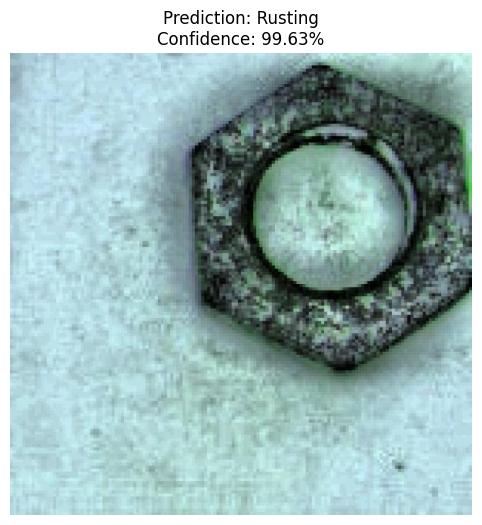


Top-5 predictions:
Rusting         99.63%
Excellent       0.29%
Fracture        0.06%
Scratches       0.01%
Deformation     0.01%
Prediction from loaded model: Rusting with confidence 99.63%


In [19]:
# Model saving was handled during training to save the 'best' model.
# The best model is saved at: /content/best_efficientnet_b0.pth
print(f"Best model saved at: {'/content/best_efficientnet_b0.pth'}")

# Additionally, save class names and transforms for inference (optional, but good practice)
import json

model_config = {
    'num_classes': len(class_names),
    'class_names': class_names,
    'mean': MEAN,
    'std': STD,
    'input_size': 224 # EfficientNet-B0 default
}

with open('/content/model_config.json', 'w') as f:
    json.dump(model_config, f)

print(f"Model configuration saved at: {'/content/model_config.json'}")

# Demonstrate loading the saved model and performing inference
print("\n--- Demonstrating Loading Saved Model ---")

# Load config
with open('/content/model_config.json', 'r') as f:
    loaded_config = json.load(f)

loaded_num_classes = loaded_config['num_classes']
loaded_class_names = loaded_config['class_names']
loaded_mean = loaded_config['mean']
loaded_std = loaded_config['std']
loaded_input_size = loaded_config['input_size']

# Recreate model structure
loaded_model = build_model(loaded_num_classes) # Use the helper to ensure correct structure
loaded_model.load_state_dict(torch.load('/content/best_efficientnet_b0.pth', map_location=device))
loaded_model.eval()
loaded_model.to(device)

# Create transform for inference
loaded_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(loaded_input_size),
    transforms.ToTensor(),
    transforms.Normalize(loaded_mean, loaded_std)
])

print("Model and configuration loaded successfully.")

# Perform inference using the loaded model
example_image_path_loaded = random.choice(val_dataset.imgs)[0]
print(f"\nPerforming prediction with loaded model for image: {example_image_path_loaded}")
predicted_class_loaded, confidence_loaded = predict_image(
    loaded_model, example_image_path_loaded, loaded_class_names, device, loaded_transform
)

print(f"Prediction from loaded model: {predicted_class_loaded} with confidence {confidence_loaded*100:.2f}%")


In [21]:
from google.colab import files

files.download('/content/best_efficientnet_b0.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
files.download('/content/model_config.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Final Results Summary

In [20]:
print("="*40)
print("FINAL MODEL RESULTS".center(40))
print("="*40)
print(f"\nModel: EfficientNet-B0")
print(f"Pretrained: ImageNet")
print(f"Number of classes: {len(class_names)}")

# Find the epoch with the best validation F1 score from combined history
combined_val_f1 = history_stage1['val_f1'] + history_stage2['val_f1']
best_epoch_idx = np.argmax(combined_val_f1)
best_val_f1_overall = combined_val_f1[best_epoch_idx]

# Assuming that the final_accuracy, final_macro_f1, final_weighted_f1 are from the best model.
print(f"\nBest Epoch (based on Val F1 during training): {best_epoch_idx + 1}")
print(f"Validation Accuracy (Best Model): {final_accuracy*100:.2f}%")
print(f"Macro F1 (Best Model): {final_macro_f1*100:.2f}%")
print(f"Weighted F1 (Best Model): {final_weighted_f1*100:.2f}%")

print(f"\nBest Model Saved Path:")
print(f" /content/best_efficientnet_b0.pth")
print("="*40)

# Analyze F1-scores per class from the classification report
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

class_f1_scores = {cls: report_dict[cls]['f1-score'] for cls in class_names}

highest_f1_class = max(class_f1_scores, key=class_f1_scores.get)
lowest_f1_class = min(class_f1_scores, key=class_f1_scores.get)

print(f"\nClass with highest F1-score: {highest_f1_class} ({class_f1_scores[highest_f1_class]*100:.2f}%) ")
print(f"Class with lowest F1-score: {lowest_f1_class} ({class_f1_scores[lowest_f1_class]*100:.2f}%) ")

print("\nMost frequently confused classes (True -> Predicted):")
if confused_pairs:
    for i, (true_cls, pred_cls, proportion) in enumerate(confused_pairs[:3]): # Show top 3
        print(f"  {i+1}. {true_cls} often confused as {pred_cls} ({proportion*100:.2f}% of {true_cls} images)")
else:
    print("  No significant confusion patterns observed.")


          FINAL MODEL RESULTS           

Model: EfficientNet-B0
Pretrained: ImageNet
Number of classes: 5

Best Epoch (based on Val F1 during training): 30
Validation Accuracy (Best Model): 98.41%
Macro F1 (Best Model): 97.98%
Weighted F1 (Best Model): 98.43%

Best Model Saved Path:
 /content/best_efficientnet_b0.pth

Class with highest F1-score: Fracture (99.13%) 
Class with lowest F1-score: Excellent (94.03%) 

Most frequently confused classes (True -> Predicted):
  1. Scratches often confused as Excellent (2.11% of Scratches images)
  2. Fracture often confused as Deformation (1.72% of Fracture images)
  3. Deformation often confused as Excellent (1.63% of Deformation images)


1. Loading model configuration...
Config loaded!
Classes: ['Deformation', 'Excellent', 'Fracture', 'Rusting', 'Scratches']
Number of classes: 5
Input size: 224

2. Creating model architecture...
Model architecture created!

3. Loading saved weights...
Weights loaded successfully!

4. Setting model to evaluation mode...
Model ready for inference!

5. Creating inference transform...
Transform created successfully!

6. Selecting test image...
Test image:
/content/extracted_dataset/nutsv2ifolder_split/val/Scratches/1_2021-11-17-00_27_41-860959_jpg.rf.63d8681cef105bc9a855d1bb9567c48d.jpg

7. Running prediction...


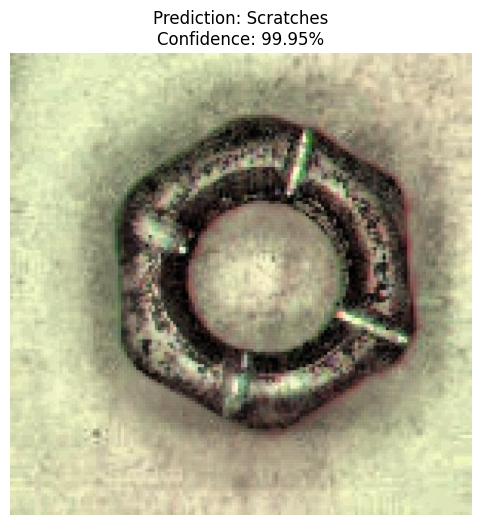


Top-5 predictions:
Scratches       99.95%
Rusting         0.04%
Excellent       0.01%
Fracture        0.00%
Deformation     0.00%

FINAL PREDICTION
Predicted class: Scratches
Confidence: 99.95%


In [25]:
print("1. Loading model configuration...")

with open('/content/model_config.json', 'r') as f:
    loaded_config = json.load(f)

loaded_num_classes = loaded_config['num_classes']
loaded_class_names = loaded_config['class_names']
loaded_mean = loaded_config['mean']
loaded_std = loaded_config['std']
loaded_input_size = loaded_config['input_size']

print("Config loaded!")
print("Classes:", loaded_class_names)
print("Number of classes:", loaded_num_classes)
print("Input size:", loaded_input_size)


print("\n2. Creating model architecture...")

loaded_model = build_model(loaded_num_classes)

print("Model architecture created!")


print("\n3. Loading saved weights...")

model_path = '/content/best_efficientnet_b0.pth'

loaded_model.load_state_dict(
    torch.load(model_path, map_location=device)
)

print("Weights loaded successfully!")


print("\n4. Setting model to evaluation mode...")

loaded_model.eval()
loaded_model.to(device)

print("Model ready for inference!")


print("\n5. Creating inference transform...")

loaded_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(loaded_input_size),
    transforms.ToTensor(),
    transforms.Normalize(
        loaded_mean,
        loaded_std
    )
])

print("Transform created successfully!")


print("\n6. Selecting test image...")

example_image_path_loaded = random.choice(val_dataset.imgs)[0]

print("Test image:")
print(example_image_path_loaded)


print("\n7. Running prediction...")

predicted_class_loaded, confidence_loaded = predict_image(
    loaded_model,
    example_image_path_loaded,
    loaded_class_names,
    device,
    loaded_transform
)

print("\n================================")
print("FINAL PREDICTION")
print("================================")
print("Predicted class:", predicted_class_loaded)
print(f"Confidence: {confidence_loaded * 100:.2f}%")